In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'font.family': 'serif', 'mathtext.fontset': 'cm'})

# New Data (UpdatedEstData) - PK/PD Visualization & Correlation Analysis

In [2]:
# Load data
df = pd.read_csv('Data/UpdatedEstData.csv')
df.columns = [c.strip().upper() for c in df.columns]

df_obs = df[(df['EVID'] == 0) & (df['MDV'] == 0)].copy()
df_dose = df[df['EVID'] == 1].copy()

pk = df_obs[df_obs['DVID'] == 1].copy()
pd_df = df_obs[df_obs['DVID'] == 2].copy()

print(f'PK obs: {len(pk)}, PD obs: {len(pd_df)}')
print(f'Patients: {df_obs["ID"].nunique()}')
print(f'Doses: {sorted(df_obs["DOSE"].unique())}')
display(df_obs.describe())

PK obs: 864, PD obs: 1200
Patients: 48
Doses: [0.0, 0.1, 0.3, 1.0]


,ID,BW,DOSE,TIME,DV,EVID,MDV,AMT,CMT,DVID
count,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000,2064.0,2064.0,2064.0,2064.000000,2064.000000
mean,27.011628,92.160853,0.398837,365.058140,5.267622,0.0,0.0,0.0,2.581395,1.581395
std,12.868395,21.344877,0.392907,335.208866,4.429335,0.0,0.0,0.0,0.493450,0.493450
min,1.000000,51.000000,0.000000,0.000000,0.001824,0.0,0.0,0.0,2.000000,1.000000
25%,17.000000,74.000000,0.100000,24.000000,1.047662,0.0,0.0,0.0,2.000000,1.000000
50%,27.000000,96.000000,0.300000,480.000000,5.021500,0.0,0.0,0.0,3.000000,2.000000
75%,38.000000,109.000000,1.000000,504.000000,7.457723,0.0,0.0,0.0,3.000000,2.000000
max,48.000000,129.000000,1.000000,1176.000000,26.275400,0.0,0.0,0.0,3.000000,2.000000


In [3]:
# Match PK and PD by patient and time
pk_pivot = pk.groupby(['ID', 'TIME'])['DV'].first().reset_index().rename(columns={'DV': 'PK'})
pd_pivot = pd_df.groupby(['ID', 'TIME'])['DV'].first().reset_index().rename(columns={'DV': 'PD'})

merged = pd.merge(pk_pivot, pd_pivot, on=['ID', 'TIME'], how='inner')
merged = pd.merge(merged, df_obs[['ID', 'DOSE', 'BW']].drop_duplicates('ID'), on='ID')

print(f'Matched PK-PD pairs: {len(merged)}')
print(f'Patients with both PK+PD at same timepoint: {merged["ID"].nunique()}')
display(merged.head(10))

Matched PK-PD pairs: 864
Patients with both PK+PD at same timepoint: 36


,ID,TIME,PK,PD,DOSE,BW
0,13,1,0.054180,4.82992,0.1,111
1,13,2,0.068870,4.97411,0.1,111
2,13,4,0.058465,4.96382,0.1,111
3,13,8,0.070060,5.73974,0.1,111
4,13,12,0.056610,4.88865,0.1,111
5,13,24,0.066635,5.77194,0.1,111
6,13,36,0.120761,6.71164,0.1,111
7,13,48,0.105931,7.88337,0.1,111
8,13,72,0.162735,6.69587,0.1,111
9,13,168,0.293529,8.57833,0.1,111


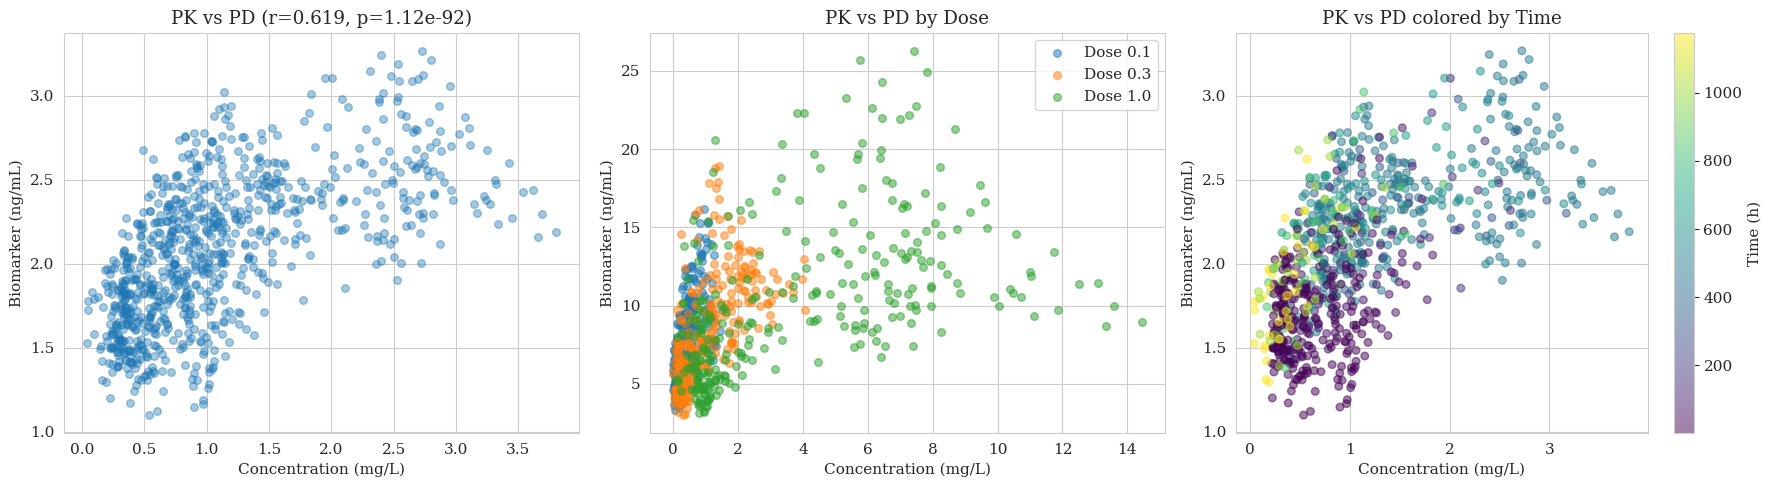

In [18]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pk_value = np.sqrt(merged['PK'])
pd_value = np.log(merged['PD'])

# (a) Overall PK vs PD
ax = axes[0]
ax.scatter(pk_value, pd_value, alpha=0.4, s=30)
r, p = stats.pearsonr(pk_value, pd_value)
ax.set_xlabel('Concentration (mg/L)')
ax.set_ylabel('Biomarker (ng/mL)')
ax.set_title(f'PK vs PD (r={r:.3f}, p={p:.2e})')

# (b) Colored by dose
ax = axes[1]
for dose in sorted(merged['DOSE'].unique()):
    sub = merged[merged['DOSE'] == dose]
    ax.scatter(sub['PK'], sub['PD'], alpha=0.5, s=30, label=f'Dose {dose}')
ax.set_xlabel('Concentration (mg/L)')
ax.set_ylabel('Biomarker (ng/mL)')
ax.set_title('PK vs PD by Dose')
ax.legend()

# (c) Colored by time
ax = axes[2]
sc = ax.scatter(pk_value, pd_value, c=merged['TIME'], cmap='viridis', alpha=0.5, s=30)
plt.colorbar(sc, ax=ax, label='Time (h)')
ax.set_xlabel('Concentration (mg/L)')
ax.set_ylabel('Biomarker (ng/mL)')
ax.set_title('PK vs PD colored by Time')

plt.tight_layout()
plt.show()

## 2. Correlation Analysis

In [5]:
# Per-dose correlation
print('=== PK-PD Correlation per Dose Group ===')
for dose in sorted(merged['DOSE'].unique()):
    sub = merged[merged['DOSE'] == dose]
    if len(sub) > 2:
        r_pearson, p_pearson = stats.pearsonr(sub['PK'], sub['PD'])
        r_spearman, p_spearman = stats.spearmanr(sub['PK'], sub['PD'])
        print(f'Dose {dose:>4}: n={len(sub):>3}, Pearson r={r_pearson:+.3f} (p={p_pearson:.3e}), Spearman r={r_spearman:+.3f} (p={p_spearman:.3e})')
    else:
        print(f'Dose {dose:>4}: n={len(sub):>3} (too few)')

=== PK-PD Correlation per Dose Group ===
Dose  0.1: n=288, Pearson r=+0.646 (p=2.210e-35), Spearman r=+0.710 (p=1.633e-45)
Dose  0.3: n=288, Pearson r=+0.644 (p=4.062e-35), Spearman r=+0.745 (p=3.044e-52)
Dose  1.0: n=288, Pearson r=+0.503 (p=6.891e-20), Spearman r=+0.615 (p=2.348e-31)


=== PK-PD Correlation per Patient ===


,ID,DOSE,r,p,n
30,43,1.0,0.715086,8.599914e-05,24
8,21,0.1,0.751405,2.314910e-05,24
31,44,1.0,0.762036,1.511227e-05,24
35,48,1.0,0.779737,7.064785e-06,24
28,41,1.0,0.805227,2.075826e-06,24
33,46,1.0,0.811317,1.508819e-06,24
24,37,1.0,0.813844,1.317289e-06,24
25,38,1.0,0.816431,1.143973e-06,24
5,18,0.1,0.818245,1.034877e-06,24
21,34,0.3,0.818821,1.002248e-06,24


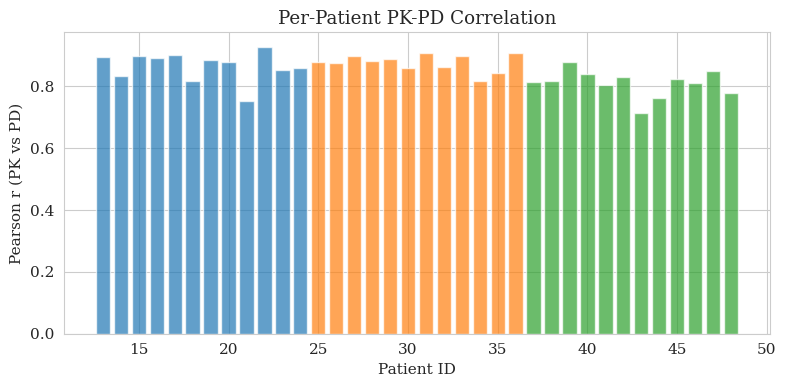

In [6]:
# Per-patient correlation
print('=== PK-PD Correlation per Patient ===')
patient_corrs = []
for pid in sorted(merged['ID'].unique()):
    sub = merged[merged['ID'] == pid]
    dose = sub['DOSE'].iloc[0]
    if len(sub) > 2:
        r, p = stats.pearsonr(sub['PK'], sub['PD'])
        patient_corrs.append({'ID': pid, 'DOSE': dose, 'r': r, 'p': p, 'n': len(sub)})

corr_df = pd.DataFrame(patient_corrs)
display(corr_df.sort_values('r'))

fig, ax = plt.subplots(figsize=(8, 4))
colors = {d: c for d, c in zip(sorted(corr_df['DOSE'].unique()), plt.cm.tab10.colors)}
for _, row in corr_df.iterrows():
    ax.bar(row['ID'], row['r'], color=colors[row['DOSE']], alpha=0.7)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Patient ID')
ax.set_ylabel('Pearson r (PK vs PD)')
ax.set_title('Per-Patient PK-PD Correlation')
plt.tight_layout()
plt.show()

## 3. Time Series per Dose Group

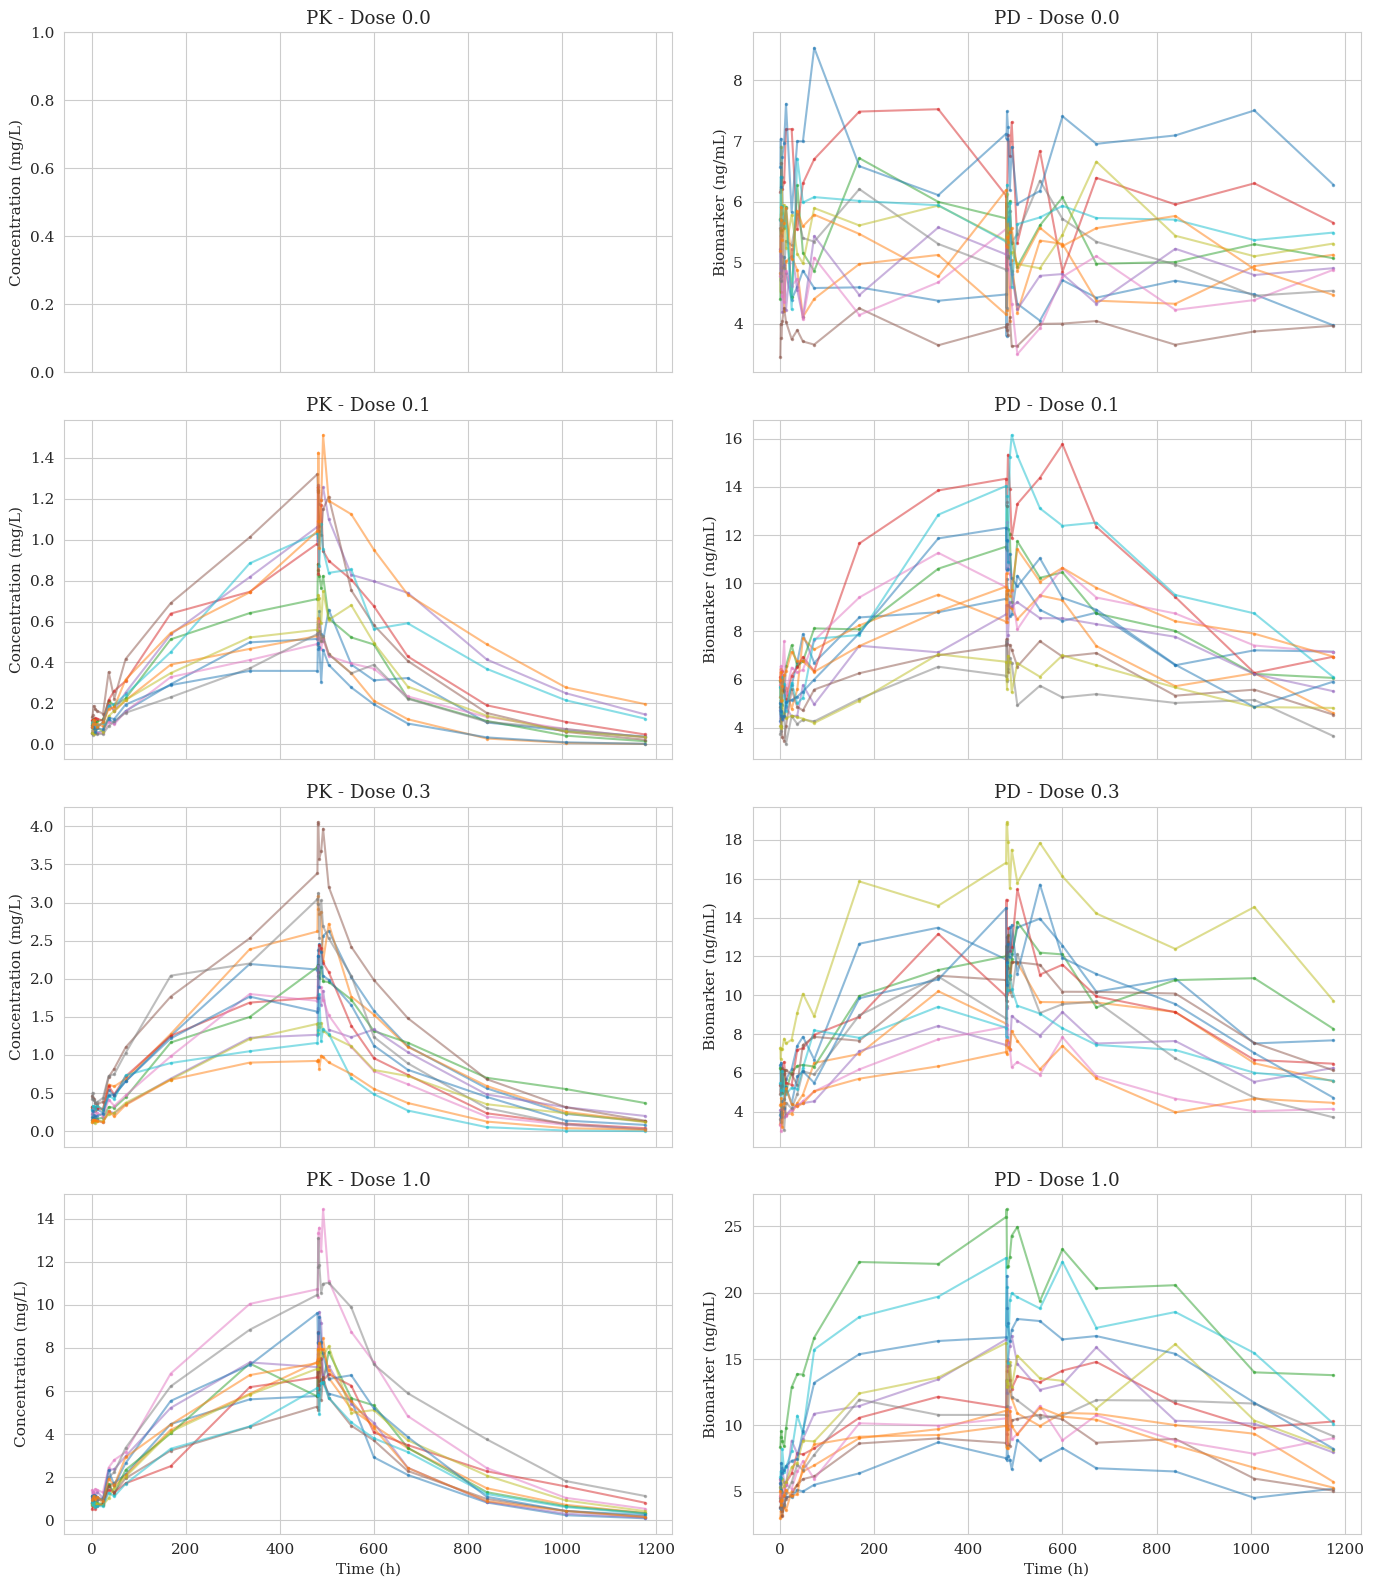

In [7]:
doses = sorted(df_obs['DOSE'].unique())
fig, axes = plt.subplots(len(doses), 2, figsize=(14, 4 * len(doses)), sharex=True)

for i, dose in enumerate(doses):
    pk_dose = pk[pk['DOSE'] == dose]
    pd_dose = pd_df[pd_df['DOSE'] == dose]
    
    # PK time series
    ax = axes[i, 0]
    for pid in pk_dose['ID'].unique():
        sub = pk_dose[pk_dose['ID'] == pid].sort_values('TIME')
        ax.plot(sub['TIME'], sub['DV'], alpha=0.5, marker='.', markersize=3)
    ax.set_ylabel('Concentration (mg/L)')
    ax.set_title(f'PK - Dose {dose}')
    
    # PD time series
    ax = axes[i, 1]
    for pid in pd_dose['ID'].unique():
        sub = pd_dose[pd_dose['ID'] == pid].sort_values('TIME')
        ax.plot(sub['TIME'], sub['DV'], alpha=0.5, marker='.', markersize=3)
    ax.set_ylabel('Biomarker (ng/mL)')
    ax.set_title(f'PD - Dose {dose}')

axes[-1, 0].set_xlabel('Time (h)')
axes[-1, 1].set_xlabel('Time (h)')
plt.tight_layout()
plt.show()

## 4. PD Response Pattern: Is it Emax / Sigmoid / Linear?

Linear: params=[0.865 7.188], R2=0.2947
Emax: params=[ 5.061 10.129  1.618], R2=0.4120
Sigmoid Emax: params=[5.101 9.994 1.596 1.021], R2=0.4120
Log-linear: params=[1.671 9.291], R2=0.3791


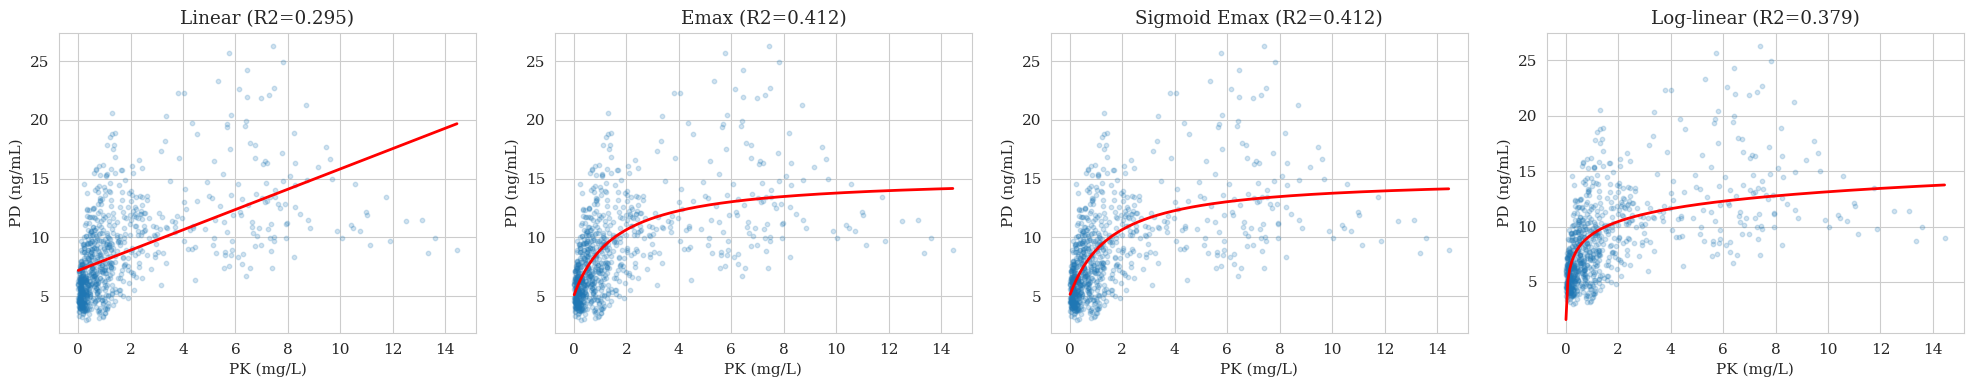

In [8]:
# Fit different PK->PD relationships
from scipy.optimize import curve_fit

x = merged['PK'].values
y = merged['PD'].values

# Remove zeros for log fits
mask = x > 0
x_pos, y_pos = x[mask], y[mask]

# Models to try
def linear(x, a, b): return a * x + b
def emax(x, e0, emax, ec50): return e0 + emax * x / (ec50 + x)
def sigmoid(x, e0, emax, ec50, n): return e0 + emax * x**n / (ec50**n + x**n)
def log_linear(x, a, b): return a * np.log(x + 1e-6) + b

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
x_fit = np.linspace(0.01, x.max(), 200)

models = [
    ('Linear', linear, [1, 5], x, y),
    ('Emax', emax, [5, 10, 2], x, y),
    ('Sigmoid Emax', sigmoid, [5, 10, 2, 1], x_pos, y_pos),
    ('Log-linear', log_linear, [1, 5], x_pos, y_pos),
]

for ax, (name, func, p0, xd, yd) in zip(axes, models):
    ax.scatter(xd, yd, alpha=0.2, s=10)
    try:
        popt, _ = curve_fit(func, xd, yd, p0=p0, maxfev=10000)
        y_pred = func(x_fit, *popt)
        ss_res = np.sum((yd - func(xd, *popt))**2)
        ss_tot = np.sum((yd - yd.mean())**2)
        r2 = 1 - ss_res / ss_tot
        ax.plot(x_fit, y_pred, 'r-', lw=2)
        ax.set_title(f'{name} (R2={r2:.3f})')
        print(f'{name}: params={np.round(popt, 3)}, R2={r2:.4f}')
    except Exception as e:
        ax.set_title(f'{name} (failed)')
        print(f'{name}: FAILED - {e}')
    ax.set_xlabel('PK (mg/L)')
    ax.set_ylabel('PD (ng/mL)')

plt.tight_layout()
plt.show()

## 5. Placebo vs Dosed - PD Baseline

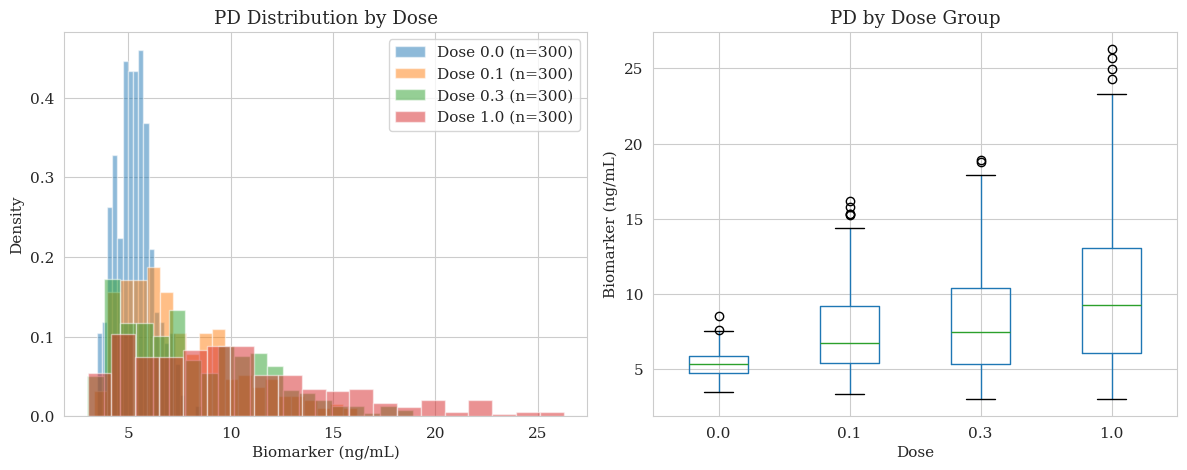

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PD distribution by dose
ax = axes[0]
for dose in sorted(pd_df['DOSE'].unique()):
    sub = pd_df[pd_df['DOSE'] == dose]['DV']
    ax.hist(sub, bins=20, alpha=0.5, label=f'Dose {dose} (n={len(sub)})', density=True)
ax.set_xlabel('Biomarker (ng/mL)')
ax.set_ylabel('Density')
ax.set_title('PD Distribution by Dose')
ax.legend()

# Boxplot
ax = axes[1]
pd_df.boxplot(column='DV', by='DOSE', ax=ax)
ax.set_xlabel('Dose')
ax.set_ylabel('Biomarker (ng/mL)')
ax.set_title('PD by Dose Group')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 6. Lagged PK-PD Correlation (PD response delay)

Lag   0h: r=+0.5492, p=4.685e-72, n=900
Lag  12h: r=+0.5162, p=2.758e-50, n=720
Lag  24h: r=+0.5420, p=7.168e-29, n=360
Lag  48h: r=+0.5255, p=1.351e-11, n=144
Lag  72h: r=+0.5295, p=3.820e-09, n=108
Lag  96h: r=+0.4004, p=4.927e-04, n=72


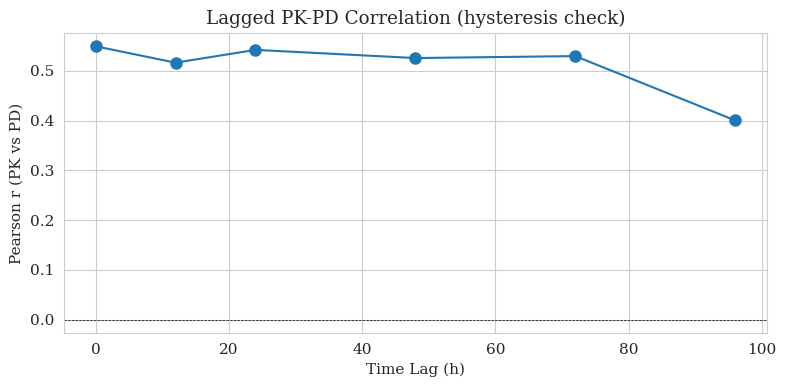

In [10]:
# Check if PD correlates better with earlier PK values (hysteresis)
# For each PD observation, find PK at different time lags

lags = [0, 12, 24, 48, 72, 96]  # hours
lag_corrs = []

for lag in lags:
    pairs = []
    for pid in pd_df['ID'].unique():
        pk_subj = pk[pk['ID'] == pid].sort_values('TIME')
        pd_subj = pd_df[pd_df['ID'] == pid].sort_values('TIME')
        
        if len(pk_subj) == 0:
            continue
        
        for _, pd_row in pd_subj.iterrows():
            target_time = pd_row['TIME'] - lag
            if target_time < 0:
                continue
            # Find closest PK measurement
            time_diff = np.abs(pk_subj['TIME'].values - target_time)
            closest_idx = time_diff.argmin()
            if time_diff[closest_idx] < 24:  # within 24h tolerance
                pairs.append((pk_subj.iloc[closest_idx]['DV'], pd_row['DV']))
    
    if len(pairs) > 2:
        pk_vals, pd_vals = zip(*pairs)
        r, p = stats.pearsonr(pk_vals, pd_vals)
        lag_corrs.append({'lag': lag, 'r': r, 'p': p, 'n': len(pairs)})
        print(f'Lag {lag:>3}h: r={r:+.4f}, p={p:.3e}, n={len(pairs)}')

lag_df = pd.DataFrame(lag_corrs)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lag_df['lag'], lag_df['r'], 'o-', markersize=8)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Time Lag (h)')
ax.set_ylabel('Pearson r (PK vs PD)')
ax.set_title('Lagged PK-PD Correlation (hysteresis check)')
plt.tight_layout()
plt.show()

## 7. Compare Old vs New Data

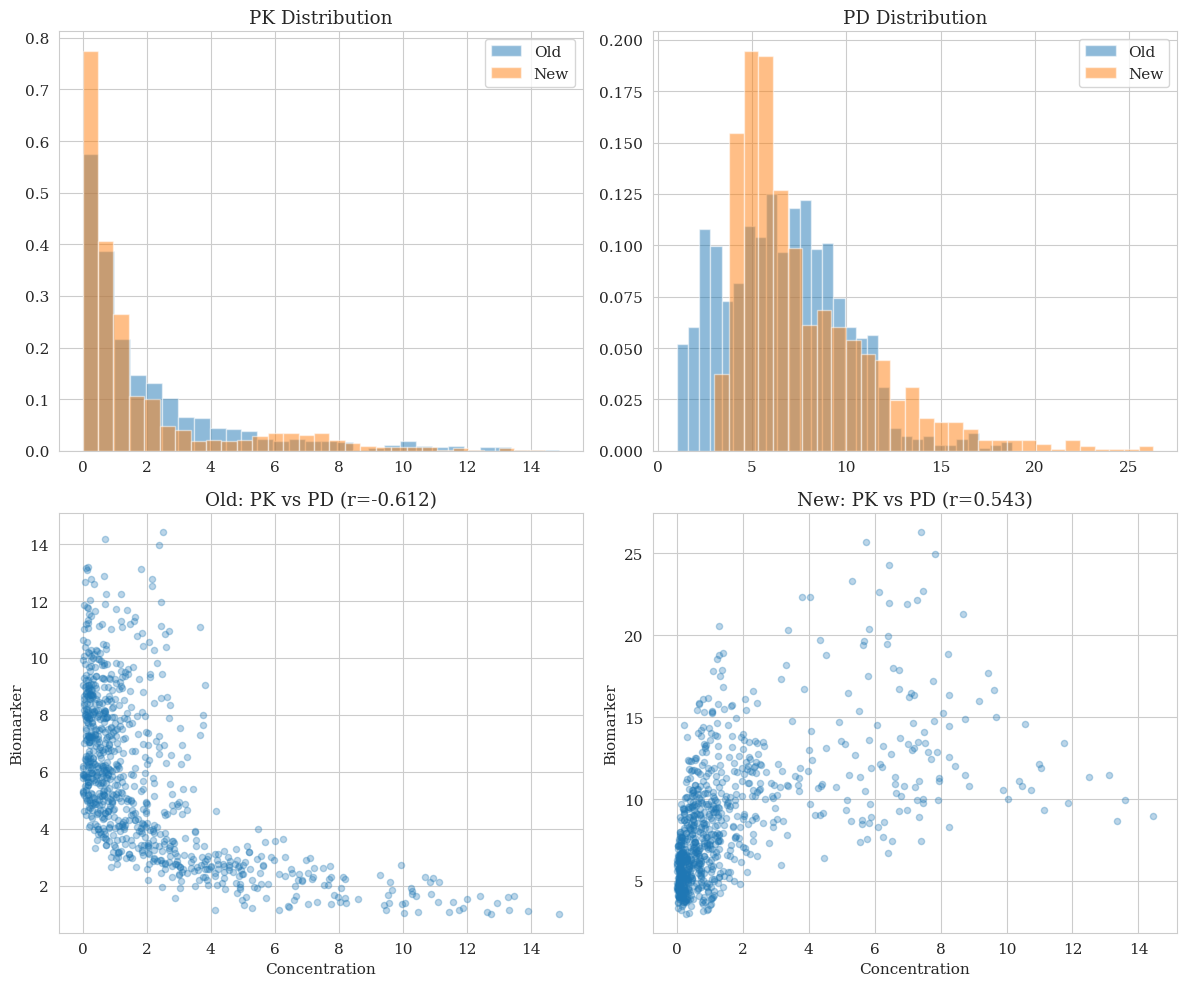

In [11]:
old = pd.read_csv('Data/QIC2025-EstDat.csv')
old.columns = [c.strip().upper() for c in old.columns]
old_obs = old[(old['EVID'] == 0) & (old['MDV'] == 0)]

old_pk = old_obs[old_obs['DVID'] == 1]
old_pd = old_obs[old_obs['DVID'] == 2]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# PK distribution
axes[0,0].hist(old_pk['DV'], bins=30, alpha=0.5, label='Old', density=True)
axes[0,0].hist(pk['DV'], bins=30, alpha=0.5, label='New', density=True)
axes[0,0].set_title('PK Distribution')
axes[0,0].legend()

# PD distribution
axes[0,1].hist(old_pd['DV'], bins=30, alpha=0.5, label='Old', density=True)
axes[0,1].hist(pd_df['DV'], bins=30, alpha=0.5, label='New', density=True)
axes[0,1].set_title('PD Distribution')
axes[0,1].legend()

# Old PK vs PD
old_pk_piv = old_pk.groupby(['ID','TIME'])['DV'].first().reset_index().rename(columns={'DV':'PK'})
old_pd_piv = old_pd.groupby(['ID','TIME'])['DV'].first().reset_index().rename(columns={'DV':'PD'})
old_merged = pd.merge(old_pk_piv, old_pd_piv, on=['ID','TIME'], how='inner')

axes[1,0].scatter(old_merged['PK'], old_merged['PD'], alpha=0.3, s=20)
r_old, _ = stats.pearsonr(old_merged['PK'], old_merged['PD'])
axes[1,0].set_title(f'Old: PK vs PD (r={r_old:.3f})')
axes[1,0].set_xlabel('Concentration')
axes[1,0].set_ylabel('Biomarker')

# New PK vs PD
axes[1,1].scatter(merged['PK'], merged['PD'], alpha=0.3, s=20)
r_new, _ = stats.pearsonr(merged['PK'], merged['PD'])
axes[1,1].set_title(f'New: PK vs PD (r={r_new:.3f})')
axes[1,1].set_xlabel('Concentration')
axes[1,1].set_ylabel('Biomarker')

plt.tight_layout()
plt.show()

## 8. Improve PK-PD Correlation - Transform Exploration

In [12]:
# ============================
# 8a. Transform PK and/or PD
# ============================
# Try all combinations of transforms to find best correlation

transforms = {
    'raw': lambda x: x,
    'log': lambda x: np.log1p(x),
    'sqrt': lambda x: np.sqrt(x),
    '1/x': lambda x: 1.0 / (x + 1e-6),
    'x^2': lambda x: x ** 2,
}

x_raw = merged['PK'].values
y_raw = merged['PD'].values

print('=== PK transform vs PD transform: Pearson r ===')
print(f'{"":>8}', end='')
for pd_name in transforms:
    print(f'{pd_name:>10}', end='')
print()

best_r, best_combo = 0, ''
for pk_name, pk_fn in transforms.items():
    print(f'{pk_name:>8}', end='')
    for pd_name, pd_fn in transforms.items():
        try:
            xt = pk_fn(x_raw)
            yt = pd_fn(y_raw)
            valid = np.isfinite(xt) & np.isfinite(yt)
            r, p = stats.pearsonr(xt[valid], yt[valid])
            print(f'{r:>+10.3f}', end='')
            if abs(r) > abs(best_r):
                best_r = r
                best_combo = f'PK={pk_name}, PD={pd_name}'
        except:
            print(f'{"err":>10}', end='')
    print()

print(f'\nBest: {best_combo} -> r={best_r:+.4f}')

=== PK transform vs PD transform: Pearson r ===
               raw       log      sqrt       1/x       x^2
     raw    +0.543    +0.538    +0.544    -0.488    +0.509
     log    +0.627    +0.633    +0.635    -0.586    +0.575
    sqrt    +0.617    +0.622    +0.625    -0.576    +0.566
     1/x    -0.129    -0.141    -0.137    +0.137    -0.106
     x^2    +0.392    +0.386    +0.392    -0.348    +0.368

Best: PK=log, PD=sqrt -> r=+0.6351


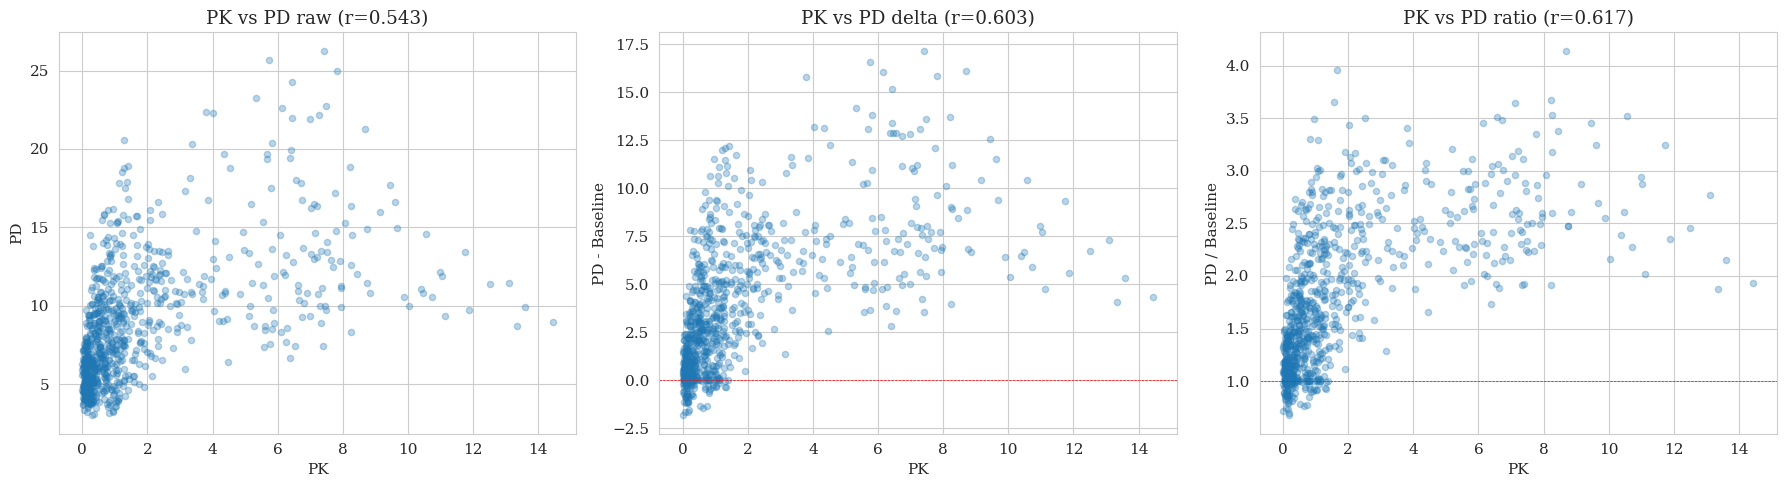

Raw r=0.5428, Delta r=0.6029, Ratio r=0.6165


In [13]:
# ============================
# 8b. Baseline-corrected PD (subtract each patient's first PD)
# ============================
merged_bc = merged.copy()
baseline_pd = merged_bc.groupby('ID')['PD'].transform('first')
merged_bc['PD_delta'] = merged_bc['PD'] - baseline_pd
merged_bc['PD_ratio'] = merged_bc['PD'] / baseline_pd

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

r0, _ = stats.pearsonr(merged_bc['PK'], merged_bc['PD'])
axes[0].scatter(merged_bc['PK'], merged_bc['PD'], alpha=0.3, s=20)
axes[0].set_title(f'PK vs PD raw (r={r0:.3f})')
axes[0].set_xlabel('PK'); axes[0].set_ylabel('PD')

r1, _ = stats.pearsonr(merged_bc['PK'], merged_bc['PD_delta'])
axes[1].scatter(merged_bc['PK'], merged_bc['PD_delta'], alpha=0.3, s=20)
axes[1].axhline(0, color='r', ls='--', lw=0.5)
axes[1].set_title(f'PK vs PD delta (r={r1:.3f})')
axes[1].set_xlabel('PK'); axes[1].set_ylabel('PD - Baseline')

r2, _ = stats.pearsonr(merged_bc['PK'], merged_bc['PD_ratio'])
axes[2].scatter(merged_bc['PK'], merged_bc['PD_ratio'], alpha=0.3, s=20)
axes[2].axhline(1, color='r', ls='--', lw=0.5)
axes[2].set_title(f'PK vs PD ratio (r={r2:.3f})')
axes[2].set_xlabel('PK'); axes[2].set_ylabel('PD / Baseline')

plt.tight_layout()
plt.show()
print(f'Raw r={r0:.4f}, Delta r={r1:.4f}, Ratio r={r2:.4f}')

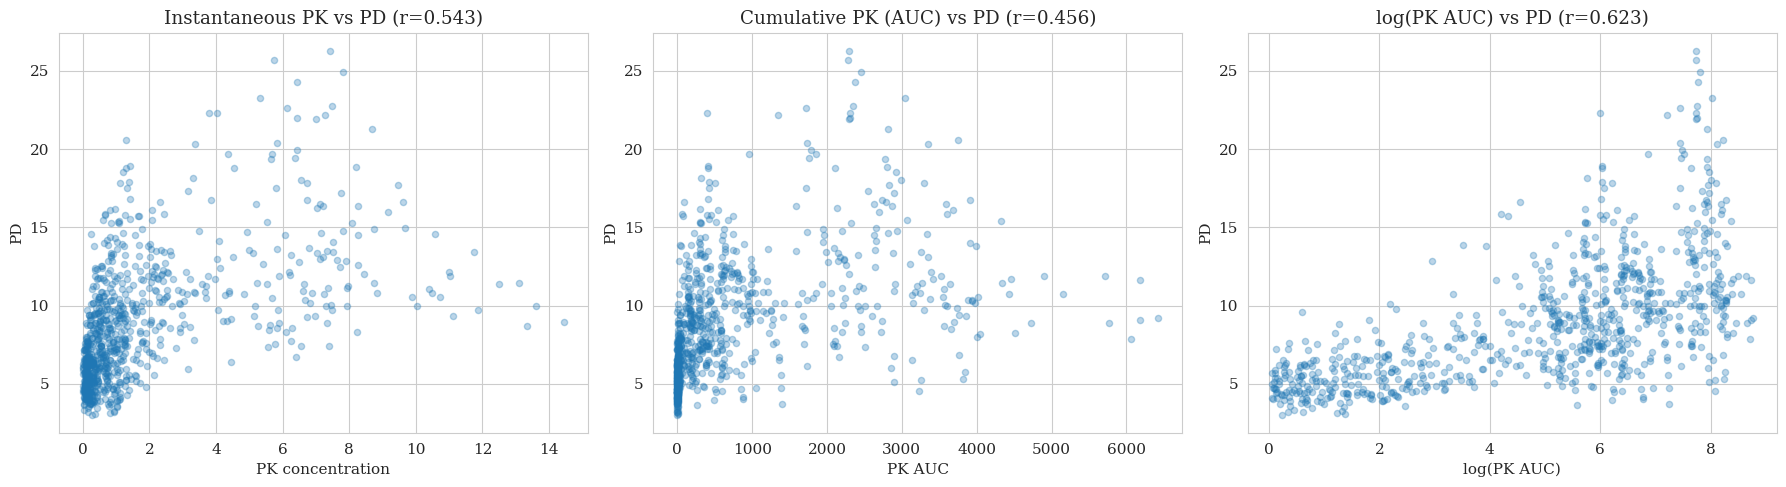

Instantaneous r=0.5428, AUC r=0.4564, log(AUC) r=0.6233


In [14]:
# ============================
# 8c. Cumulative PK exposure (AUC-like) vs PD
# ============================
merged_auc = merged.copy()

auc_values = []
for pid in merged_auc['ID'].unique():
    sub = merged_auc[merged_auc['ID'] == pid].sort_values('TIME')
    times = sub['TIME'].values
    pks = sub['PK'].values
    
    cum_auc = np.zeros(len(times))
    for j in range(1, len(times)):
        cum_auc[j] = cum_auc[j-1] + 0.5 * (pks[j] + pks[j-1]) * (times[j] - times[j-1])
    
    for idx, auc in zip(sub.index, cum_auc):
        auc_values.append((idx, auc))

auc_df = pd.DataFrame(auc_values, columns=['idx', 'PK_AUC']).set_index('idx')
merged_auc = merged_auc.join(auc_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

r0, _ = stats.pearsonr(merged_auc['PK'], merged_auc['PD'])
axes[0].scatter(merged_auc['PK'], merged_auc['PD'], alpha=0.3, s=20)
axes[0].set_title(f'Instantaneous PK vs PD (r={r0:.3f})')
axes[0].set_xlabel('PK concentration'); axes[0].set_ylabel('PD')

mask = merged_auc['PK_AUC'] > 0
r1, _ = stats.pearsonr(merged_auc.loc[mask, 'PK_AUC'], merged_auc.loc[mask, 'PD'])
axes[1].scatter(merged_auc.loc[mask, 'PK_AUC'], merged_auc.loc[mask, 'PD'], alpha=0.3, s=20)
axes[1].set_title(f'Cumulative PK (AUC) vs PD (r={r1:.3f})')
axes[1].set_xlabel('PK AUC'); axes[1].set_ylabel('PD')

r2, _ = stats.pearsonr(np.log1p(merged_auc.loc[mask, 'PK_AUC']), merged_auc.loc[mask, 'PD'])
axes[2].scatter(np.log1p(merged_auc.loc[mask, 'PK_AUC']), merged_auc.loc[mask, 'PD'], alpha=0.3, s=20)
axes[2].set_title(f'log(PK AUC) vs PD (r={r2:.3f})')
axes[2].set_xlabel('log(PK AUC)'); axes[2].set_ylabel('PD')

plt.tight_layout()
plt.show()
print(f'Instantaneous r={r0:.4f}, AUC r={r1:.4f}, log(AUC) r={r2:.4f}')

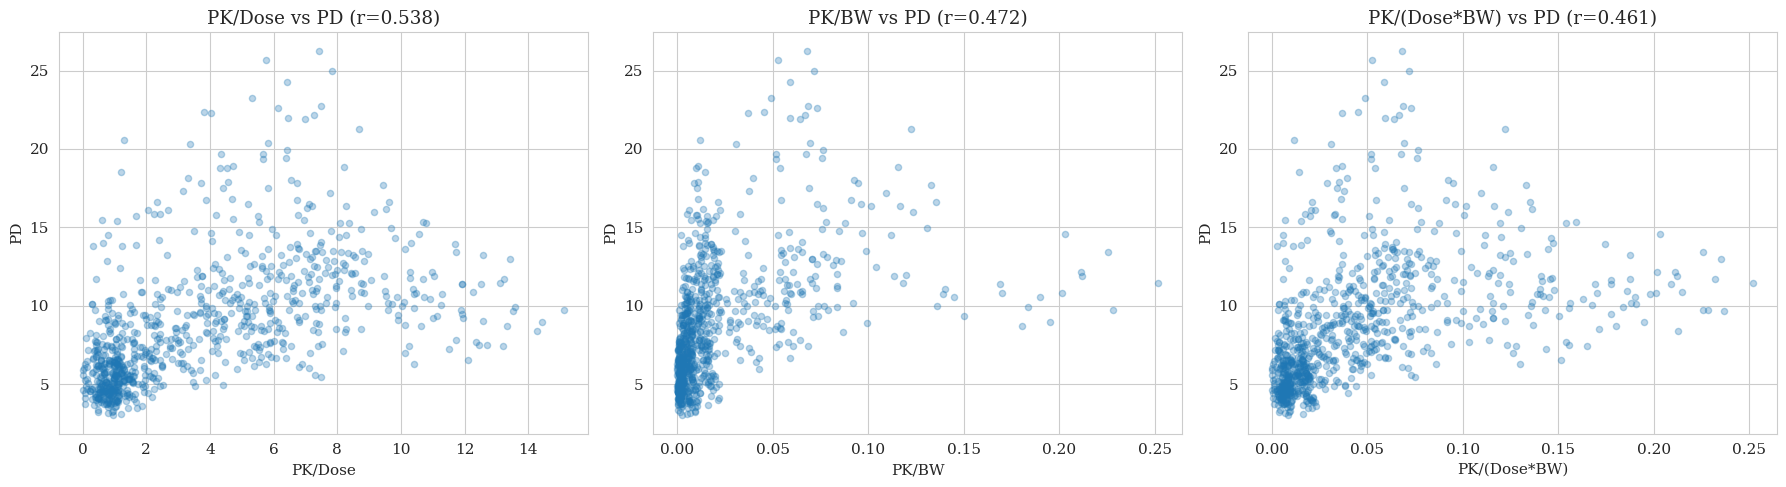

In [15]:
# ============================
# 8d. Normalize PK by dose and body weight
# ============================
merged_norm = merged.copy()

merged_norm['PK_per_dose'] = merged_norm['PK'] / merged_norm['DOSE'].replace(0, np.nan)
merged_norm['PK_per_kg'] = merged_norm['PK'] / merged_norm['BW']
merged_norm['PK_per_dose_kg'] = merged_norm['PK'] / (merged_norm['DOSE'].replace(0, np.nan) * merged_norm['BW'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, label in zip(axes, 
    ['PK_per_dose', 'PK_per_kg', 'PK_per_dose_kg'],
    ['PK/Dose', 'PK/BW', 'PK/(Dose*BW)']):
    
    valid = merged_norm[col].notna() & np.isfinite(merged_norm[col])
    xv = merged_norm.loc[valid, col].values
    yv = merged_norm.loc[valid, 'PD'].values
    r, p = stats.pearsonr(xv, yv)
    ax.scatter(xv, yv, alpha=0.3, s=20)
    ax.set_title(f'{label} vs PD (r={r:.3f})')
    ax.set_xlabel(label)
    ax.set_ylabel('PD')

plt.tight_layout()
plt.show()

In [16]:
# ============================
# 8e. Summary
# ============================
print('='*60)
print('SUMMARY: PK-PD Correlation Improvement Methods')
print('='*60)
print()
print('Run all cells above first, then check which r values are highest.')
print()
print('Actionable for model pipeline:')
print('- If log(PD) or sqrt(PD) wins: transform PD target in data_loader')
print('- If baseline correction wins: add BASELINE_PD feature')
print('- If AUC wins: add CUM_PK_AUC feature in engineer_dose_features()')
print('- If PK/BW wins: use --use_perkg flag')

SUMMARY: PK-PD Correlation Improvement Methods

Run all cells above first, then check which r values are highest.

Actionable for model pipeline:
- If log(PD) or sqrt(PD) wins: transform PD target in data_loader
- If baseline correction wins: add BASELINE_PD feature
- If AUC wins: add CUM_PK_AUC feature in engineer_dose_features()
- If PK/BW wins: use --use_perkg flag
